In [12]:
# =====================================
# IMPORTAZIONE LIBRERIE NECESSARIE
# =====================================

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from scipy.stats import chi2_contingency
from scipy.stats import mannwhitneyu
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (roc_auc_score,accuracy_score,recall_score,f1_score,confusion_matrix, roc_curve)


In [6]:
# =====================================
# CARICAMENTO DEL DATASET
# =====================================

dati = pd.read_csv('heart_failure_clinical_records.csv')
dati.head(20)
dati.info() #non sono presenti dati mancanti
#le variabili dicotomiche le ha considerate come numeriche, vanno trasformate in fattori

var_cat = ['anaemia', 'diabetes', 'high_blood_pressure', 'sex', 'smoking']
for x in var_cat:
  dati[x] = pd.Categorical(dati[x])

dati.info()

dati['anaemia'] = dati['anaemia'].map({0: 'No', 1: 'Yes'})
dati['diabetes'] = dati['diabetes'].map({0: 'No', 1: 'Yes'})
dati['high_blood_pressure'] = dati['high_blood_pressure'].map({0: 'No', 1: 'Yes'})
dati['smoking'] = dati['smoking'].map({0: 'No', 1: 'Yes'})
dati['sex'] = dati['sex'].map({0: "Female", 1: "Male"})


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       5000 non-null   float64
 1   anaemia                   5000 non-null   int64  
 2   creatinine_phosphokinase  5000 non-null   int64  
 3   diabetes                  5000 non-null   int64  
 4   ejection_fraction         5000 non-null   int64  
 5   high_blood_pressure       5000 non-null   int64  
 6   platelets                 5000 non-null   float64
 7   serum_creatinine          5000 non-null   float64
 8   serum_sodium              5000 non-null   int64  
 9   sex                       5000 non-null   int64  
 10  smoking                   5000 non-null   int64  
 11  time                      5000 non-null   int64  
 12  DEATH_EVENT               5000 non-null   int64  
dtypes: float64(3), int64(10)
memory usage: 507.9 KB
<class 'pandas.

DEATH_EVENT
0    3432
1    1568
Name: count, dtype: int64
31.36

 === Aneamia ===
anaemia
No     2628
Yes    2372
Name: count, dtype: int64
DEATH_EVENT          0          1
anaemia                          
No           71.042618  28.957382
Yes          65.978078  34.021922
0.0001314084504967406

 === Diabetes ===
diabetes
No     2803
Yes    2197
Name: count, dtype: int64
DEATH_EVENT          0          1
diabetes                         
No           68.176953  31.823047
Yes          69.230769  30.769231
0.4434246767522827

 === High Blood Pressure ===
high_blood_pressure
No     3176
Yes    1824
Name: count, dtype: int64
DEATH_EVENT                  0          1
high_blood_pressure                      
No                   71.945844  28.054156
Yes                  62.883772  37.116228
3.6715748221572216e-11

 === Sex ===
sex
Male      3228
Female    1772
Name: count, dtype: int64
DEATH_EVENT          0          1
sex                              
Female       72.121896  27.878104
Ma

/tmp/ipykernel_3699/1229930547.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x = 'DEATH_EVENT', y = 'age', data = dati, palette = 'pastel')


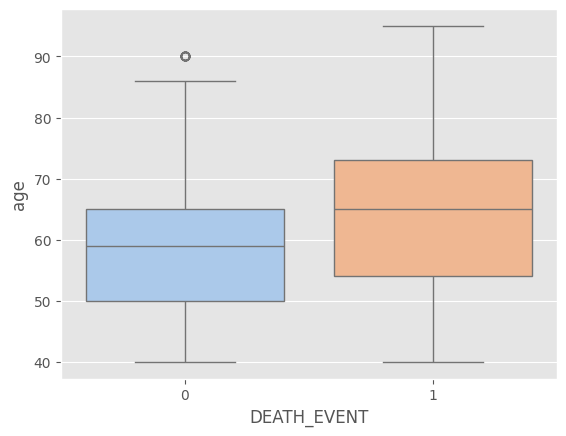

4.582976113773867e-52


/tmp/ipykernel_3699/1229930547.py:64: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x = 'DEATH_EVENT', y = 'creatinine_phosphokinase', data = dati, palette = 'pastel')


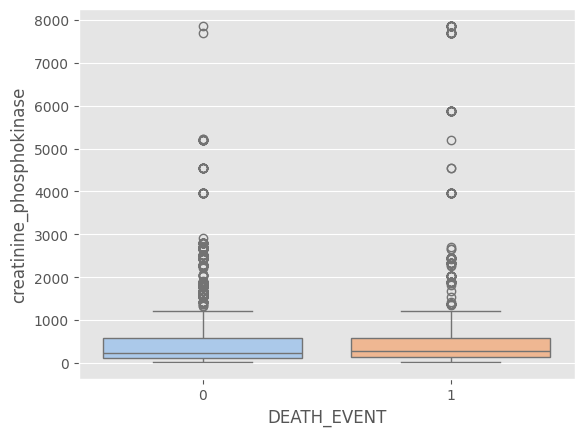

0.0008999444052098743


/tmp/ipykernel_3699/1229930547.py:72: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x = 'DEATH_EVENT', y = 'ejection_fraction', data = dati, palette = 'pastel')


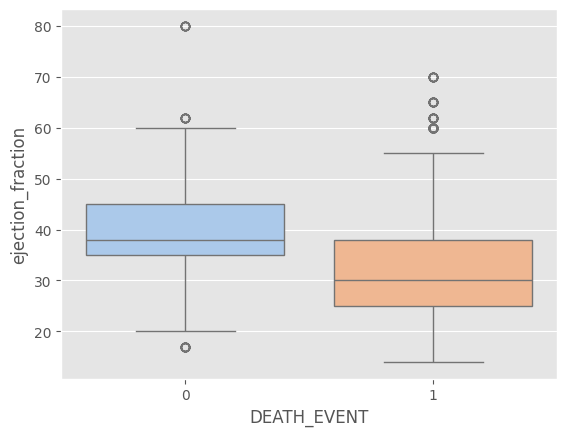

1.9120018380945836e-107


/tmp/ipykernel_3699/1229930547.py:80: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x = 'DEATH_EVENT', y = 'platelets', data = dati, palette = 'pastel')


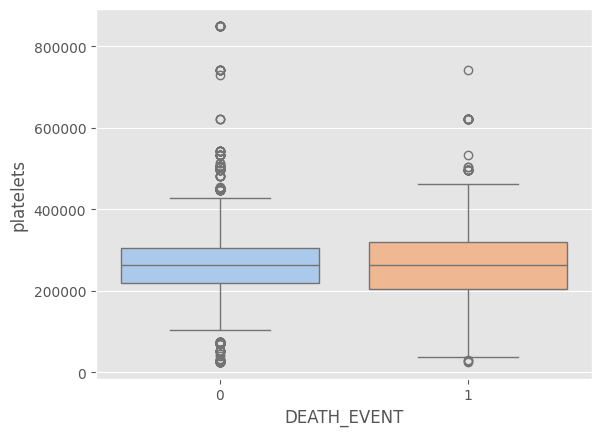

0.018962306258301597


/tmp/ipykernel_3699/1229930547.py:88: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x = 'DEATH_EVENT', y = 'serum_creatinine', data = dati, palette = 'pastel')


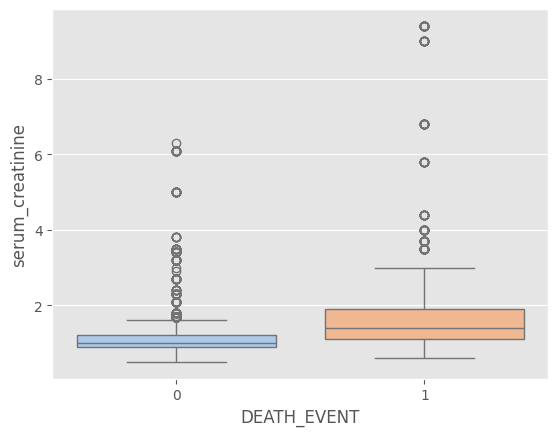

2.749333411124259e-168


/tmp/ipykernel_3699/1229930547.py:96: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x = 'DEATH_EVENT', y = 'serum_sodium', data = dati, palette = 'pastel')


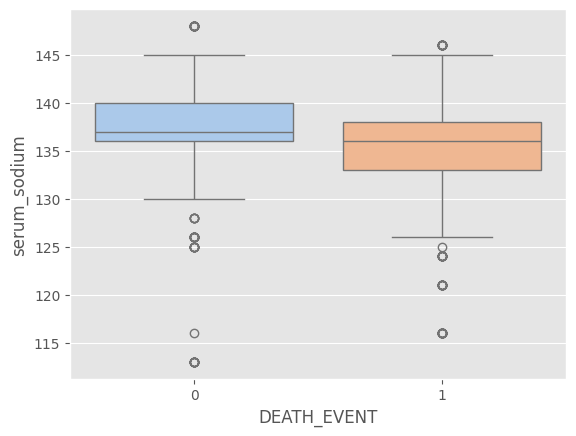

3.5297592366819715e-63


/tmp/ipykernel_3699/1229930547.py:104: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x = 'DEATH_EVENT', y = 'time', data = dati, palette = 'pastel')


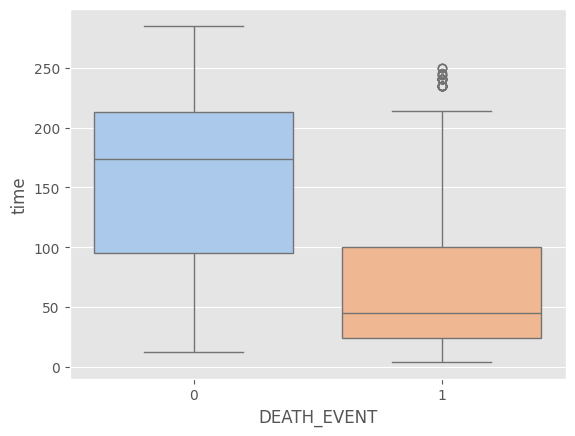

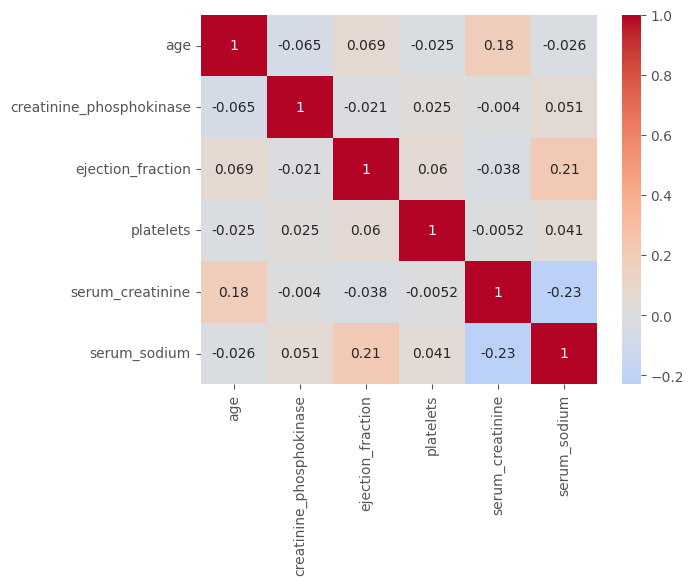

In [14]:
# =====================================
# ANALISI ESPLORATIVA
# =====================================

print(dati['DEATH_EVENT'].value_counts()) #numero di eventi
print(dati['DEATH_EVENT'].mean()*100) #proporzione di morti

#variabili categoriali

var_cat = ['anaemia', 'diabetes', 'high_blood_pressure', 'sex', 'smoking']

#Tabella

print(f'\n === {'Aneamia'} ===')
print(dati['anaemia'].value_counts())
print(pd.crosstab(dati['anaemia'], dati['DEATH_EVENT'], normalize='index')*100)
tab = pd.crosstab(dati['anaemia'], dati['DEATH_EVENT'])
chi2, p, dof, expected = chi2_contingency(tab)
print(p)

print(f'\n === {'Diabetes'} ===')
print(dati['diabetes'].value_counts())
print(pd.crosstab(dati['diabetes'], dati['DEATH_EVENT'], normalize='index')*100)
tab = pd.crosstab(dati['diabetes'], dati['DEATH_EVENT'])
chi2, p, dof, expected = chi2_contingency(tab)
print(p)

print(f'\n === {'High Blood Pressure'} ===')
print(dati['high_blood_pressure'].value_counts())
print(pd.crosstab(dati['high_blood_pressure'], dati['DEATH_EVENT'], normalize='index')*100)
tab = pd.crosstab(dati['high_blood_pressure'], dati['DEATH_EVENT'])
chi2, p, dof, expected = chi2_contingency(tab)
print(p)

print(f'\n === {'Sex'} ===')
print(dati['sex'].value_counts())
print(pd.crosstab(dati['sex'], dati['DEATH_EVENT'], normalize='index')*100)
tab = pd.crosstab(dati['sex'], dati['DEATH_EVENT'])
chi2, p, dof, expected = chi2_contingency(tab)
print(p)

print(f'\n === {'Smoking'} ===')
print(dati['smoking'].value_counts())
print(pd.crosstab(dati['smoking'], dati['DEATH_EVENT'], normalize='index')*100)
tab = pd.crosstab(dati['smoking'], dati['DEATH_EVENT'])
chi2, p, dof, expected = chi2_contingency(tab)
print(p)

#Variabili numeriche

print(dati.groupby('DEATH_EVENT')[[
    'age',
    'ejection_fraction',
    'serum_creatinine',
    'creatinine_phosphokinase',
    'platelets',
    'serum_sodium',
    'time'
]].median())

plt.style.use("ggplot")

sns.boxplot(x = 'DEATH_EVENT', y = 'age', data = dati, palette = 'pastel')
plt.show()

gr0 = dati[dati['DEATH_EVENT']==0]['age']
gr1 = dati[dati['DEATH_EVENT']==1]['age']
stat, p = mannwhitneyu(gr0, gr1)
print(p)

sns.boxplot(x = 'DEATH_EVENT', y = 'creatinine_phosphokinase', data = dati, palette = 'pastel')
plt.show()

gr0 = dati[dati['DEATH_EVENT']==0]['creatinine_phosphokinase']
gr1 = dati[dati['DEATH_EVENT']==1]['creatinine_phosphokinase']
stat, p = mannwhitneyu(gr0, gr1)
print(p)

sns.boxplot(x = 'DEATH_EVENT', y = 'ejection_fraction', data = dati, palette = 'pastel')
plt.show()

gr0 = dati[dati['DEATH_EVENT']==0]['ejection_fraction']
gr1 = dati[dati['DEATH_EVENT']==1]['ejection_fraction']
stat, p = mannwhitneyu(gr0, gr1)
print(p)

sns.boxplot(x = 'DEATH_EVENT', y = 'platelets', data = dati, palette = 'pastel')
plt.show()

gr0 = dati[dati['DEATH_EVENT']==0]['platelets']
gr1 = dati[dati['DEATH_EVENT']==1]['platelets']
stat, p = mannwhitneyu(gr0, gr1)
print(p)

sns.boxplot(x = 'DEATH_EVENT', y = 'serum_creatinine', data = dati, palette = 'pastel')
plt.show()

gr0 = dati[dati['DEATH_EVENT']==0]['serum_creatinine']
gr1 = dati[dati['DEATH_EVENT']==1]['serum_creatinine']
stat, p = mannwhitneyu(gr0, gr1)
print(p)

sns.boxplot(x = 'DEATH_EVENT', y = 'serum_sodium', data = dati, palette = 'pastel')
plt.show()

gr0 = dati[dati['DEATH_EVENT']==0]['serum_sodium']
gr1 = dati[dati['DEATH_EVENT']==1]['serum_sodium']
stat, p = mannwhitneyu(gr0, gr1)
print(p)

sns.boxplot(x = 'DEATH_EVENT', y = 'time', data = dati, palette = 'pastel')
plt.show()

num_var = ['age','creatinine_phosphokinase','ejection_fraction','platelets','serum_creatinine','serum_sodium']
corr = dati[num_var].corr()
sns.heatmap(corr, annot=True,cmap='coolwarm',center=0)
plt.show()

# =====================================
# RISULTATI ANALISI ESPLORATIVA
# =====================================

# Dall’analisi esplorativa emerge che alcune variabili categoriali
# risultano associate in modo più evidente all’outcome (DEATH_EVENT).

# In particolare:
# - il sesso maschile mostra una percentuale più alta di eventi (morte)
#   rispetto al sesso femminile (circa 33% vs 27%)
# - i pazienti con ipertensione presentano una maggiore incidenza di morte
#   rispetto ai non ipertesi (circa 37% vs 28%)
# - i pazienti anemici mostrano anch’essi una percentuale più elevata di eventi
#   rispetto ai non anemici (circa 34% vs 29%)
#
# Al contrario, la variabile diabete non mostra differenze evidenti
# nella probabilità di evento tra le due classi.

# =====================================
# VARIABILI NUMERICHE
# =====================================

# Per quanto riguarda le variabili continue, emergono alcune associazioni importanti:

# - i pazienti che hanno avuto l’evento (morte) tendono ad essere più anziani
#   rispetto a quelli che non l’hanno avuto
# - la frazione di eiezione (ejection_fraction) risulta più bassa nei pazienti deceduti,
#   indicando una minore capacità cardiaca
# - la creatinina sierica è più alta nei pazienti deceduti, suggerendo peggior funzione renale
# - il tempo di follow-up (time) risulta più basso nei pazienti che muoiono,
#   ma questa variabile va interpretata con cautela nel contesto del machine learning

# =====================================
# ANALISI MULTICOLLINEARITÀ
# =====================================

# È stata calcolata la matrice di correlazione tra le variabili numeriche
# per verificare la presenza di multicollinearità.

# I risultati mostrano che le correlazioni tra le variabili sono generalmente basse,
# con valori lontani dalla soglia critica (|corr| > 0.7).

# La correlazione più elevata in valore assoluto è tra:
# serum_creatinine e serum_sodium (-0.23 circa),
# che risulta comunque debole.

# Pertanto, non emergono problemi di multicollinearità rilevanti
# che possano influenzare la stabilità dei modelli statistici.

# =====================================
# LA VARIABILE "time"
# =====================================

# La variabile "time" rappresenta il periodo di follow-up del paziente,
# cioè il tempo trascorso fino all’evento o fino alla fine dell’osservazione.

# Questa variabile non verrà utilizzata nel modello predittivo perché:
#
# - contiene un'informazione temporale legata direttamente all’evento
# - può introdurre data leakage, cioè informazione "quasi futura"
# - non rappresenta una caratteristica clinica del paziente al momento iniziale
#   (come età, pressione, ecc)
#
# Per questo motivo "time" viene esclusa dal set di feature utilizzato nei modelli.


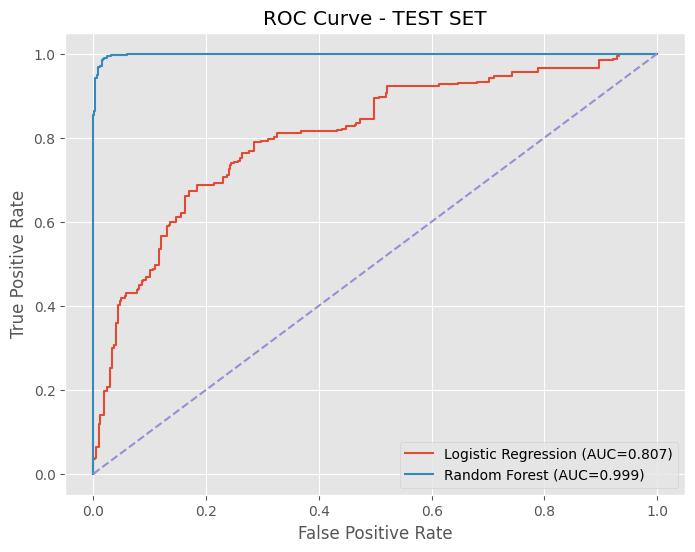

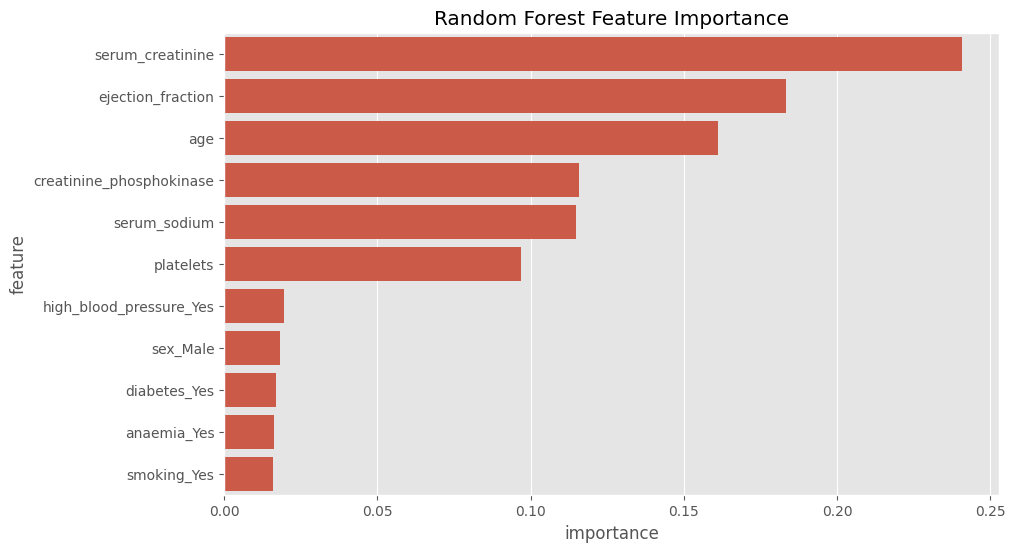

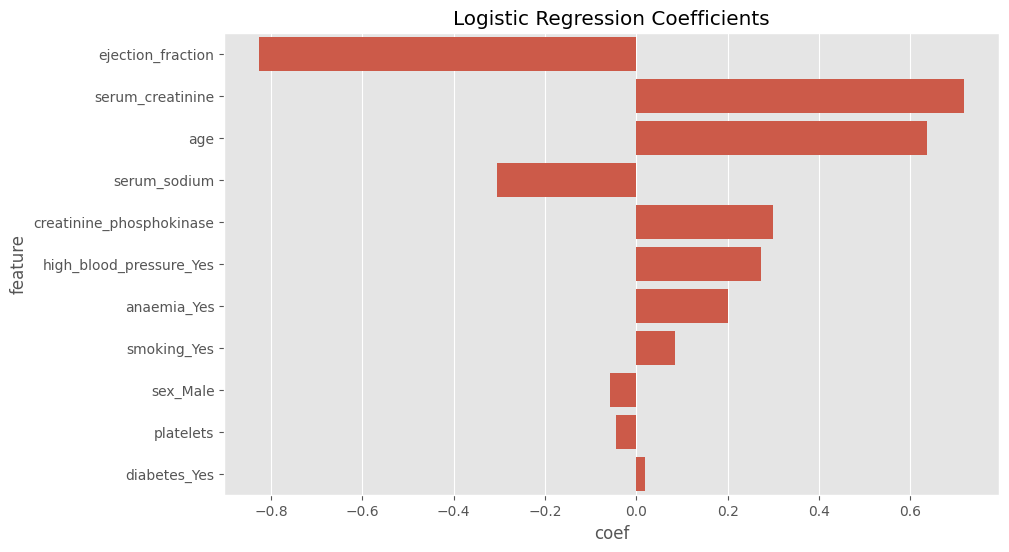


AUC LOGISTIC TEST: 0.8068420270747061
AUC RANDOM FOREST TEST: 0.9988393901691706


In [15]:
# =====================================
# PREPARAZIONE DATI
# =====================================

X = dati.drop(columns=['DEATH_EVENT', 'time']) #predittori
y = dati['DEATH_EVENT'] #variabile target (0 = vivo, 1 = morto)

# trasformazione delle variabili categoriche in variabili numeriche (0/1)
# serve perché i modelli ML lavorano solo con numeri

X = pd.get_dummies(X, columns=['anaemia', 'diabetes', 'high_blood_pressure', 'sex', 'smoking'], drop_first=True)

# =====================================
# TRAIN / TEST SPLIT
# =====================================

# separo i dati in train e test
# il test NON viene mai "visto" durante l'addestramento (serve per valutazione finale)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,   # mantiene la stessa proporzione di classi (morti/vivi)
    random_state=42
)

# =====================================
# CROSS VALIDATION + GRIGLIE IPERPARAMETRI
# =====================================

# cross validation interna per scegliere i migliori iperparametri

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)

grid_log = {'C':[0.01,0.1,1,10,100]}

# griglia per la regressione logistica
# C controlla la regolarizzazione (più piccolo = modello più semplice)

grid_rf = {
    'n_estimators':[100,200,500],
    'max_depth':[3,5,10],
    'min_samples_leaf':[1,3,5]
}

# griglia per Random Forest
# n_estimators = numero alberi
# max_depth = profondità alberi
# min_samples_leaf = minimo campioni in una foglia

# =====================================
# REGRESSIONE LOGISTICA (CV SU TRAIN)
# =====================================

# standardizzazione: fondamentale per la logistica perché è basata su distanze/scale

scaler = StandardScaler()
X_train_std = scaler.fit_transform(X_train) # fit SOLO su train
X_test_std = scaler.transform(X_test)       # trasformo test con parametri del train

# grid search per trovare miglior C usando SOLO il train

log_cv = GridSearchCV(
    LogisticRegression(max_iter=5000),
    grid_log,
    scoring='roc_auc',   # ottimizza AUC
    cv=cv,
    n_jobs=-1
)

log_cv.fit(X_train_std, y_train)

# estraggo il miglior parametro trovato

best_C = log_cv.best_params_['C']

# modello finale logistica addestrato su tutto il train

log_final = LogisticRegression(C=best_C, max_iter=5000)
log_final.fit(X_train_std, y_train)

# =====================================
# RANDOM FOREST (CV SU TRAIN)
# =====================================

# random forest NON ha bisogno di standardizzazione
# perché gli alberi non dipendono dalla scala delle variabili

rf_cv = GridSearchCV(
    RandomForestClassifier(random_state=123),
    grid_rf,
    scoring='roc_auc',
    cv=cv,
    n_jobs=-1
)

rf_cv.fit(X_train, y_train)

# migliori parametri trovati

best_rf = rf_cv.best_params_

# modello finale random forest

rf_final = RandomForestClassifier(
    n_estimators=best_rf['n_estimators'],
    max_depth=best_rf['max_depth'],
    min_samples_leaf=best_rf['min_samples_leaf'],
    random_state=123
)

rf_final.fit(X_train, y_train)

# =====================================
# VALUTAZIONE SU TEST SET
# =====================================

# probabilità previste (servono per ROC e AUC)

prob_log = log_final.predict_proba(X_test_std)[:,1]
prob_rf = rf_final.predict_proba(X_test)[:,1]

# classi previste (0 o 1)

pred_log = log_final.predict(X_test_std)
pred_rf = rf_final.predict(X_test)

# AUC finale sul test set (misura qualità discriminante reale)

auc_log = roc_auc_score(y_test, prob_log)
auc_rf = roc_auc_score(y_test, prob_rf)

# ROC curve (serve per grafico)

fpr_log, tpr_log, _ = roc_curve(y_test, prob_log)
fpr_rf, tpr_rf, _ = roc_curve(y_test, prob_rf)

# =====================================
# GRAFICO ROC CURVE
# =====================================

plt.figure(figsize=(8,6))

plt.plot(fpr_log, tpr_log, label=f'Logistic Regression (AUC={auc_log:.3f})')
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC={auc_rf:.3f})')

# linea diagonale = modello casuale

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - TEST SET")
plt.legend()
plt.show()

# =====================================
# IMPORTANZA VARIABILI RANDOM FOREST
# =====================================

# quanto ogni variabile contribuisce al modello

importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': rf_final.feature_importances_
}).sort_values(by='importance', ascending=False)

plt.figure(figsize=(10,6))

sns.barplot(
    data=importance,
    x='importance',
    y='feature'
)

plt.title("Random Forest Feature Importance")
plt.show()

# =====================================
# COEFFICIENTI REGRESSIONE LOGISTICA
# =====================================

# i coefficienti indicano direzione e forza dell’effetto

coef = pd.DataFrame({
    'feature': X_train.columns,
    'coef': log_final.coef_[0]
})

# ordino per importanza assoluta

coef['abs'] = coef['coef'].abs()
coef = coef.sort_values('abs', ascending=False)

plt.figure(figsize=(10,6))

sns.barplot(
    data=coef,
    x='coef',
    y='feature'
)

plt.title("Logistic Regression Coefficients")
plt.show()

# =====================================
# INTERPRETAZIONE REGRESSIONE LOGISTICA E RANDOM FOREST
# =====================================

# Dall’analisi dei coefficienti della regressione logistica emergono alcune evidenze interessanti.

# Le variabili con maggiore impatto (in valore assoluto) sono:
# - ejection_fraction (coefficiente negativo)
# - serum_creatinine (coefficiente positivo)
# - age (coefficiente positivo)

# In particolare:
# - una maggiore ejection_fraction è associata a una riduzione del rischio di morte,
#   indicando un effetto protettivo della funzione cardiaca
# - livelli più alti di creatinina sierica sono associati a un aumento del rischio,
#   coerente con una peggior funzione renale
# - l’età più elevata è associata a un rischio maggiore di evento

# Le altre variabili, sia cliniche che binarie (diabete, fumo, sesso),
# mostrano coefficienti più contenuti, quindi un impatto minore nel modello lineare.

# =====================================
# RANDOM FOREST - IMPORTANZA VARIABILI
# =====================================

# La Random Forest conferma in larga parte i risultati della regressione logistica.

# Le variabili più importanti risultano:
# - serum_creatinine
# - ejection_fraction
# - age
# - creatinine_phosphokinase
# - serum_sodium

# Anche in questo caso, le variabili cliniche principali (funzione cardiaca e renale)
# dominano la capacità predittiva del modello.

# Le variabili categoriali (sesso, fumo, diabete, ipertensione, anemia)
# risultano invece poco informative nel modello complessivo.

# =====================================
# RISULTATI FINALI
# =====================================

print("\nAUC LOGISTIC TEST:", auc_log)
print("AUC RANDOM FOREST TEST:", auc_rf)

# =====================================
# COMMENTO RISULTATI FINALI (AUC)
# =====================================

# Dal confronto delle performance sul test set emerge una differenza molto marcata
# tra i due modelli in termini di capacità discriminante (AUC).

# La regressione logistica ottiene un AUC pari a circa 0.81,
# indicando una buona capacità di distinguere tra pazienti deceduti e sopravvissuti,
# ma con un approccio più lineare e quindi meno flessibile.

# La Random Forest raggiunge invece un AUC estremamente elevato (~0.999),
# suggerendo una capacità quasi perfetta di separazione delle classi.

# Tale risultato indica che il modello ad alberi riesce a catturare pattern
# non lineari molto forti presenti nei dati.

# In sintesi:
# - la regressione logistica fornisce una baseline solida e interpretabile
# - la Random Forest massimizza la performance predittiva, ma con minore interpretabilità

In [ ]:
# =====================================
# CONCLUSIONI FINALI DEL PROGETTO
# =====================================

# In questo lavoro è stata effettuata un’analisi completa di machine learning
# sul dataset "heart failure clinical records", con l’obiettivo di prevedere
# l’evento di morte nei pazienti affetti da insufficienza cardiaca.

# Il processo ha incluso:
# - analisi esplorativa dei dati (EDA)
# - studio delle relazioni tra variabili e outcome
# - preparazione del dataset e encoding delle variabili categoriche
# - costruzione di un train/test split stratificato
# - ottimizzazione degli iperparametri tramite cross-validation
# - confronto tra regressione logistica e Random Forest
# - valutazione finale su test set tramite metriche e AUC
# - analisi dell’importanza delle variabili

# =====================================
# RISULTATI PRINCIPALI
# =====================================

# Entrambi i modelli evidenziano che le variabili più rilevanti sono:
# - ejection_fraction (funzione cardiaca)
# - serum_creatinine (funzione renale)
# - age (condizione fisiologica del paziente)

# La regressione logistica mostra una performance buona ma realistica
# (AUC ≈ 0.81), coerente con un modello lineare interpretabile.

# La Random Forest invece raggiunge prestazioni estremamente elevate
# (AUC ≈ 0.999), indicando una quasi perfetta capacità discriminante.

# =====================================
# INTERPRETAZIONE DEI RISULTATI E POSSIBILI CAUSE
# =====================================

# Risultati così elevati, in particolare per la Random Forest, devono essere
# interpretati con cautela.

# Le possibili spiegazioni sono:
#
# 1) Forte separabilità del dataset:
#    alcune variabili cliniche sono naturalmente molto informative
#    e permettono di distinguere quasi direttamente i due gruppi.
#
# 2) Presenza di pattern non lineari:
#    la Random Forest riesce a catturare interazioni complesse tra variabili
#    che la regressione logistica non può modellare.
#
# 3) Dimensione limitata del dataset:
#    essendo un dataset relativamente piccolo, i modelli ad alta capacità
#    possono adattarsi molto bene ai pattern presenti.
#
# 4) Possibile effetto di variabili fortemente predittive:
#    alcune feature cliniche (come funzione cardiaca e renale)
#    possono avere un potere predittivo molto elevato sull’outcome.

# =====================================
# CONSIDERAZIONE FINALE
# =====================================

# In conclusione, il lavoro mostra che:
# - il problema è altamente predicibile già con pochi indicatori clinici
# - i modelli non lineari migliorano significativamente le performance
# - le variabili più importanti sono coerenti con la letteratura medica

# Tuttavia, le performance estremamente elevate della Random Forest
# suggeriscono che il problema sia probabilmente “facile” dal punto di vista
# statistico oppure fortemente guidato da poche variabili molto informative.

# Il modello logistico rimane comunque fondamentale come baseline interpretabile,
# mentre la Random Forest rappresenta il modello più performante in termini
# predittivi.